# DETECCIÓ DE LLENGIATGE TÒXIC EN TEXTOS CURTS

## Maria Muñoz Cabestany

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import classification_report, confusion_matrix, f1_score,ConfusionMatrixDisplay, precision_recall_curve
import matplotlib.pyplot as plt
import html
import re
from wordcloud import WordCloud

from collections import Counter
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from scipy.sparse import hstack

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/TFG/labeled_data.csv")
df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she look like a tranny
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you hear about me might be true or it might be faker than the bitch who told it to ya &#57361;


# Anàlisi exploratòria de les dades (EDA)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB


In [ ]:
# unificació d'etiquetatge per fer classificació binaria
df["label"] = df["class"].apply(lambda x: 0 if x == 2 else 1)
# class 0 i 1 -> tòxic (1)
# class 2 -> no tòxic (0)

df["label"].value_counts()

,count
label,
1,20620
0,4163


Text(0.5, 1.0, 'CLasses')

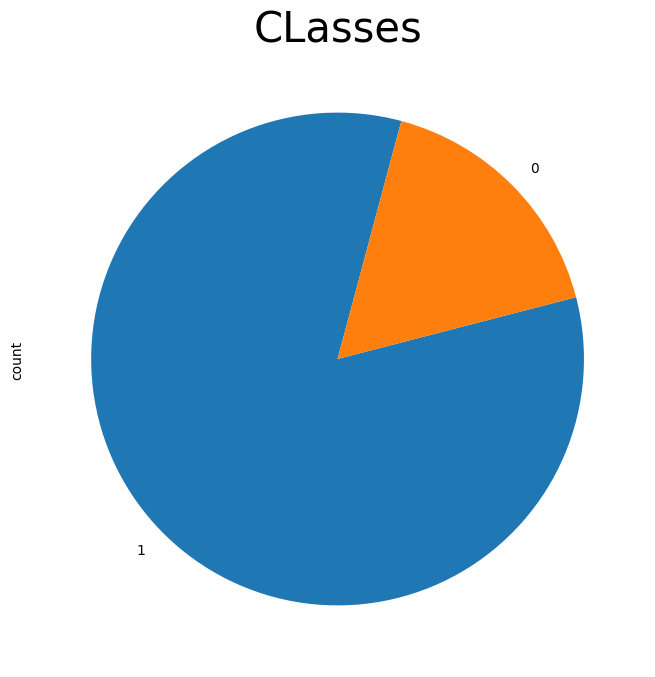

In [ ]:
df['label'].value_counts().plot.pie(figsize=(10,8), startangle=75)

plt.title('CLasses', fontsize=30)

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
df["tweet"].sample(20)

,tweet
10912,I swear I heard that bitch creak
5521,@andrewzoudo @BlVckbricks I'm still gonna smack the fuck out them. They trying to act hard over twitter. Haha pussy ass niggas
3294,@GossipCop screw the little porch monkey!
19185,"RT @iLoveyou_Autumn: Bruhhhhh, I want some Oreos and milk. &#128553;"
8261,But they only talk on twitter bc pussies in real life
7734,And ha bitch break down my weed sometimes
1642,&#8220;@_ImtrILLasFuk: Snap Chat Names please? &#128527;&#128171;&#128166;&#8221;only bitch you can Snapchatt is me
15580,"RT @I_FloodsYaTL: ""@ZariaVonMars: Um http://t.co/Cuue9Vvc2M"" exactly how most of these hoes twat is setup..."
8888,Dumb ass student gets trapped in a giant #pussy sculpture http://t.co/5IzMLkvZZV #germany #wtf #funny #hornymen
20196,"RT @tishforprez: you had me at ""eating pussy""."


# Preprocessament del text

In [ ]:
emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # Emoticons
        u"\U0001F300-\U0001F5FF"  # Symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # Transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # Flags
        u"\U00002700-\U000027BF"  # Dingbats
        u"\U0001F900-\U0001F9FF"  # Supplemental Symbols & Pictographs
        u"\U00002600-\U000026FF"  # Misc symbols
        "]+",
        flags=re.UNICODE
    )

In [ ]:
def cleaning_text(text):
    text = re.sub(r'^[\'"`“”‘’]+', '', text).strip()
    text = re.sub(r'^[\s\'"`“”‘’!}]*RT\s+', '', text, flags=re.IGNORECASE).strip()
    text = re.sub(r'^[!}]+', '', text)
    text = re.sub(r'@\S+', '', text).strip()
    text = re.sub(r'http\S+|www\.\S+', '', text).strip()
    text = text.replace("/", '').replace('>', '')
    text = html.unescape(text)
    text = text.replace("&", "")
    text = re.sub(r'\s+', ' ', text).strip()
    text=emoji_pattern.sub(r'', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    return text

In [ ]:
df["clean_text"] = df["tweet"].apply(cleaning_text)

In [ ]:
df[["tweet", "clean_text"]].sample(10)

,tweet,clean_text
4948,@TheOneMiss_Luu no he's an asshole &amp; is like I have neck problems &amp; can't sleep that way &#128544; u lil bitch,no he's an asshole is like I have neck problems can't sleep that way u lil bitch
17081,RT @ReeseZamora: @daxmw23 Dax we don't love these hoes,Dax we don't love these hoes
9334,Fucking pussy bruh lol,Fucking pussy bruh lol
16882,RT @Permatrippin: How i eat the pussy http://t.co/kdFHDx8yDT,How i eat the pussy
23442,"You want me on the couch playing video games where you can see me or out with my friends with other pussy in reach, bae?","You want me on the couch playing video games where you can see me or out with my friends with other pussy in reach, bae?"
17712,RT @TheRealIceTre: Finna hit this bitch with a handful of salt http://t.co/uaBiQvI6a6,Finna hit this bitch with a handful of salt
7766,And you kno we the opposite of down bitch we up http://t.co/qkFYwnFZqu,And you kno we the opposite of down bitch we up
7112,@t__amil i tell it how it is if yu ain uh bitch or uh hoe i call yu by yo name,i tell it how it is if yu ain uh bitch or uh hoe i call yu by yo name
6947,"@ruby_knox @all_about_kk @squirtnetwork Why would i pay sex ,when i can getfree pussy that makes no sence at all","Why would i pay sex ,when i can getfree pussy that makes no sence at all"
8726,Did this bitch really just ask me do I have a badge to be in this building while going to my floor. White people just don't change at all.,Did this bitch really just ask me do I have a badge to be in this building while going to my floor. White people just don't change at all.


In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
count,0
hate_speech,0
offensive_language,0
neither,0
class,0
tweet,0
label,0
clean_text,0


In [ ]:
df["clean_text"] = df["clean_text"].replace("", np.nan)

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
count,0
hate_speech,0
offensive_language,0
neither,0
class,0
tweet,0
label,0
clean_text,1


In [ ]:
df[df["clean_text"].isna()].head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,label,clean_text
6098,6274,3,0,2,1,1,@hoes &#9829;,1,NaN


In [ ]:
df = df.dropna(subset=["clean_text"])

# Segon EDA

In [ ]:
df["label"].value_counts()

,count
label,
1,20619
0,4163


Text(0.5, 1.0, 'CLasses')

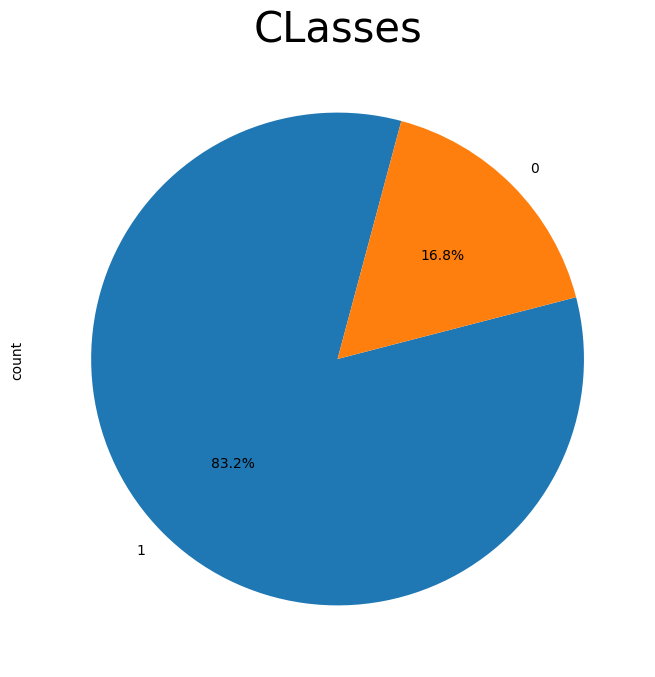

In [ ]:
df['label'].value_counts().plot.pie(figsize=(10,8), startangle=75,autopct='%1.1f%%')

plt.title('CLasses', fontsize=30)

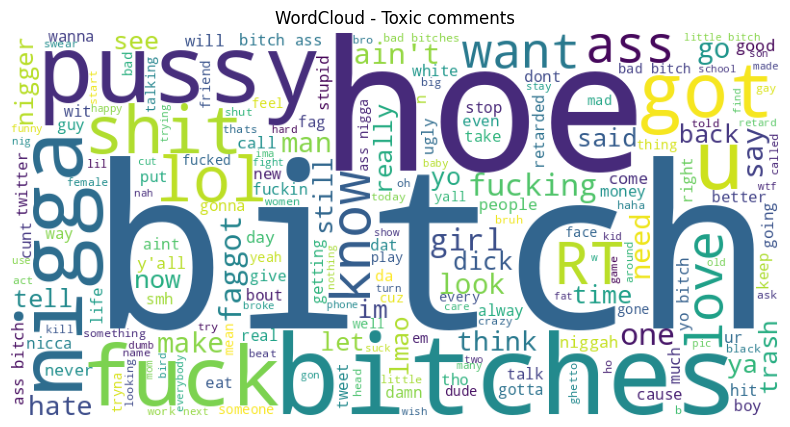

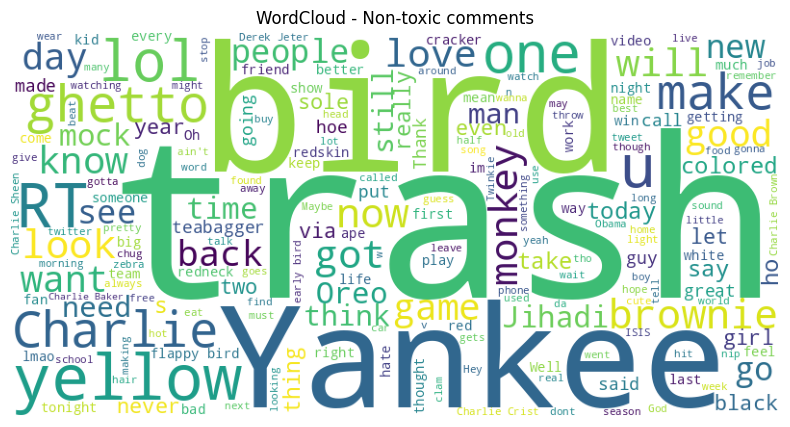

In [ ]:
toxic_text = " ".join(df[df["label"] == 1]["clean_text"])
non_toxic_text = " ".join(df[df["label"] == 0]["clean_text"])

wordcloud_toxic = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(toxic_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_toxic)
plt.axis("off")
plt.title("WordCloud - Toxic comments")
plt.show()


wordcloud_non_toxic = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(non_toxic_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_non_toxic)
plt.axis("off")
plt.title("WordCloud - Non-toxic comments")
plt.show()

In [ ]:
text = " ".join(df["clean_text"])

words = text.split()

word_counts = Counter(words)

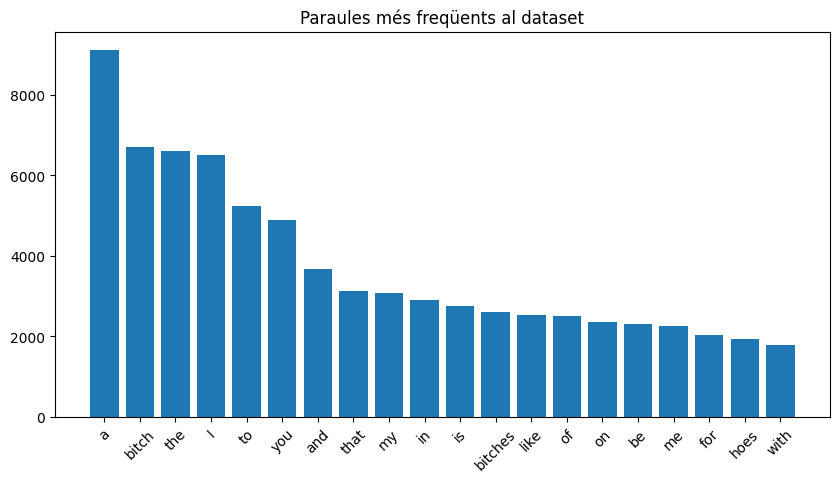

In [ ]:
top_words = word_counts.most_common(20)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Paraules més freqüents al dataset")
plt.show()

In [ ]:


toxic_text = " ".join(df[df["label"] == 1]["clean_text"])
clean_text = " ".join(df[df["label"] == 0]["clean_text"])
toxic_counts = Counter(toxic_text.split())
clean_counts = Counter(clean_text.split())
all_words = Counter(" ".join(df["clean_text"]).split())
top_words = [w for w, _ in all_words.most_common(20)]
toxic_freq = [toxic_counts[w] for w in top_words]
clean_freq = [clean_counts[w] for w in top_words]

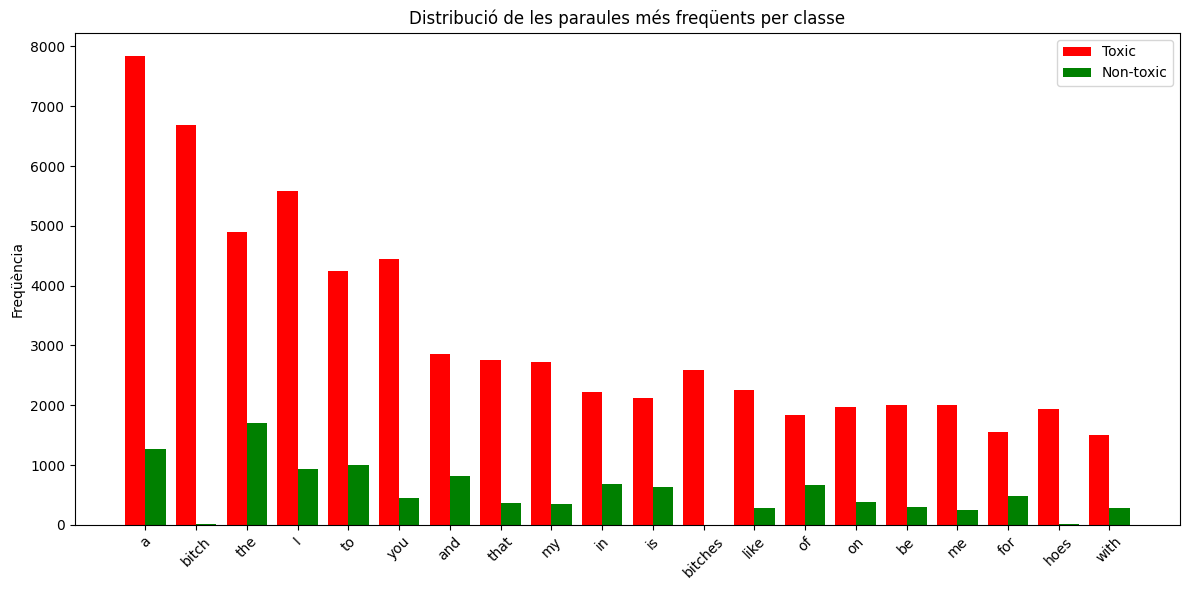

In [ ]:

x = np.arange(len(top_words))
width = 0.4

plt.figure(figsize=(12,6))

plt.bar(x - width/2, toxic_freq, width, label="Toxic", color='red')
plt.bar(x + width/2, clean_freq, width, label="Non-toxic", color='green')

plt.xticks(x, top_words, rotation=45)
plt.ylabel("Freqüència")
plt.title("Distribució de les paraules més freqüents per classe")
plt.legend()

plt.tight_layout()
plt.show()

# Tokenització i representació del text

In [ ]:
X = df["clean_text"]
y = df["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
bow_vectorizer = CountVectorizer(
    ngram_range=(1,2),
    min_df=5
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=5
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [ ]:
print(X_train_bow.shape)
print(X_train_tfidf.shape)

(19825, 9360)
(19825, 9360)


# Models baseline

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Complement NB": ComplementNB(),
    "Bernoulli NB": BernoulliNB()

}

In [ ]:
print("RESULTATS AMB BAG-OF-WORDS")

for name, model in models.items():

    model.fit(X_train_bow, y_train)
    preds = model.predict(X_test_bow)

    f1 = f1_score(y_test, preds, average="macro")

    print(name, "F1-macro:", f1)

RESULTATS AMB BAG-OF-WORDS
Logistic Regression F1-macro: 0.9222289046361426
Linear SVM F1-macro: 0.9060272300978853
Multinomial Naive Bayes F1-macro: 0.8809118368439921
Complement NB F1-macro: 0.883163311246352
Bernoulli NB F1-macro: 0.8755410495199637


In [ ]:
print("\nRESULTATS AMB TF-IDF")

for name, model in models.items():

    model.fit(X_train_tfidf, y_train)

    preds = model.predict(X_test_tfidf)

    f1 = f1_score(y_test, preds, average="macro")

    print(name, "F1-macro:", f1)


RESULTATS AMB TF-IDF
Logistic Regression F1-macro: 0.8749763096699064
Linear SVM F1-macro: 0.9150077638557469
Multinomial Naive Bayes F1-macro: 0.7426097229412284
Complement NB F1-macro: 0.8741779278541624
Bernoulli NB F1-macro: 0.8755410495199637



#CERCA D'HIPERPARAMETRES



In [ ]:
param_grids = {

    "Logistic Regression": (
        LogisticRegression(max_iter=1000),
        {"C": [0.01, 0.1, 1, 10]
         #,"class_weight": [None, "balanced"]
         }
    ),

    "Linear SVM": (
        LinearSVC(),
        {"C": [0.01, 0.1, 1, 10]
         # ,"class_weight": [None, "balanced"]
         }
    ),

    "Multinomial NB": (
        MultinomialNB(),
        {"alpha": [0.01, 0.1, 0.5, 1,10]}
    ),

    "Complement NB": (
        ComplementNB(),
        {"alpha": [0.01, 0.1, 0.5, 1]}
    ),

    "Bernoulli NB": (
        BernoulliNB(),
        {"alpha": [0.01, 0.1, 0.5, 1]}
    )
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
print("HYPERPARAMETER TUNING — BAG OF WORDS\n")

best_models_bow = {}

for name, (model, params) in param_grids.items():

    grid = GridSearchCV(
        model,
        params,
        cv=skf,
        scoring="f1_macro",
        n_jobs=-1
    )

    grid.fit(X_train_bow, y_train)

    print(name)
    print("Best params:", grid.best_params_)
    print("Best CV score:", grid.best_score_)
    print()

    best_models_bow[name] = grid.best_estimator_

HYPERPARAMETER TUNING — BAG OF WORDS

Logistic Regression
Best params: {'C': 1}
Best CV score: 0.9145097662329886

Linear SVM
Best params: {'C': 0.1}
Best CV score: 0.9177289323341682

Multinomial NB
Best params: {'alpha': 1}
Best CV score: 0.8825900105879795

Complement NB
Best params: {'alpha': 0.5}
Best CV score: 0.8830987927901182

Bernoulli NB
Best params: {'alpha': 0.5}
Best CV score: 0.8818204159257682



In [ ]:
print("HYPERPARAMETER TUNING — TFIDF\n")

best_models_tfidf = {}

for name, (model, params) in param_grids.items():

    grid = GridSearchCV(
        model,
        params,
        cv=skf,
        scoring="f1_macro",
        n_jobs=-1
    )

    grid.fit(X_train_tfidf, y_train)

    print(name)
    print("Best params:", grid.best_params_)
    print("Best CV score:", grid.best_score_)
    print()

    best_models_tfidf[name] = grid.best_estimator_

HYPERPARAMETER TUNING — TFIDF

Logistic Regression
Best params: {'C': 10}
Best CV score: 0.8954167369592767

Linear SVM
Best params: {'C': 1}
Best CV score: 0.9007684614750933

Multinomial NB
Best params: {'alpha': 0.1}
Best CV score: 0.8137301292193927

Complement NB
Best params: {'alpha': 1}
Best CV score: 0.8647818996748079

Bernoulli NB
Best params: {'alpha': 0.5}
Best CV score: 0.8818204159257682



In [ ]:
print("FINAL RESULTS — BAG OF WORDS")

for name, model in best_models_bow.items():

    preds = model.predict(X_test_bow)

    f1 = f1_score(y_test, preds, average="macro")

    print(name, "F1-macro:", f1)

FINAL RESULTS — BAG OF WORDS
Logistic Regression F1-macro: 0.9222289046361426
Linear SVM F1-macro: 0.9263452802539336
Multinomial NB F1-macro: 0.8809118368439921
Complement NB F1-macro: 0.8822187090162846
Bernoulli NB F1-macro: 0.8884466861285257


In [ ]:
print("\nFINAL RESULTS — TFIDF")

for name, model in best_models_tfidf.items():

    preds = model.predict(X_test_tfidf)

    f1 = f1_score(y_test, preds, average="macro")

    print(name, "F1-macro:", f1)


FINAL RESULTS — TFIDF
Logistic Regression F1-macro: 0.9129333416689738
Linear SVM F1-macro: 0.9150077638557469
Multinomial NB F1-macro: 0.8205012022368358
Complement NB F1-macro: 0.8741779278541624
Bernoulli NB F1-macro: 0.8884466861285257


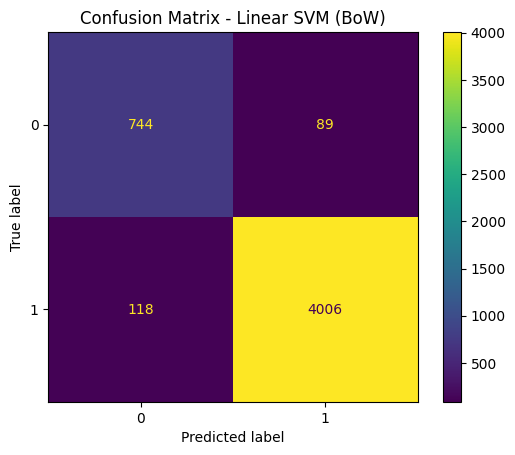

In [ ]:
best_model = best_models_bow["Linear SVM"]

preds_principal = best_model.predict(X_test_bow)
cm = confusion_matrix(y_test, preds_principal)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Linear SVM (BoW)")
plt.show()

## Dataset jigsaw

In [ ]:
jigsaw = pd.read_csv("/content/drive/MyDrive/TFG/jigsaw/train.csv")

jigsaw.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0,0,0,0,0,0
1,000103f0d9cfb60f,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominations#Transport """,0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember what page that's on?",0,0,0,0,0,0


In [ ]:
jigsaw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [ ]:
jigsaw["comment_text"].isna().sum()

np.int64(0)

In [ ]:
jigsaw["label"] = ((jigsaw["toxic"] == 1) | (jigsaw["severe_toxic"] == 1)).astype(int)

#prova canviant el label
toxicity_cols = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

jigsaw["label_all"] = jigsaw[toxicity_cols].max(axis=1)

In [ ]:
jigsaw = jigsaw.drop(columns=toxicity_cols + ["id"])

jigsaw.head()

,comment_text,label,label_all
0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0,0
1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0,0
2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",0,0
3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominations#Transport """,0,0
4,"You, sir, are my hero. Any chance you remember what page that's on?",0,0


In [ ]:
jigsaw["clean_text"] = jigsaw["comment_text"].apply(cleaning_text)

In [ ]:
jigsaw.head()

,comment_text,label,label_all,clean_text
0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0,0,"Explanation Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27"
1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0,0,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)"
2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",0,0,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info."
3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominations#Transport """,0,0,"More I can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know. There appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominationsTransport """
4,"You, sir, are my hero. Any chance you remember what page that's on?",0,0,"You, sir, are my hero. Any chance you remember what page that's on?"


## Nateja

In [ ]:
def clean(text):
  text = re.sub(r'\b\d{1,3}(?:\.\d{1,3}){3}\b', '', text) #eliminar IP addresses
  text = re.sub(r'\d{1,2}:\d{2},?\s+\w+\s+\d{1,2},\s+\d{4}', '', text) #eliminar timestamps
  #eliminar UTC
  text = re.sub(r'\(UTC\)', '', text)
  return text

In [ ]:
jigsaw["clean_text"].isna().sum()

np.int64(0)

In [ ]:
jigsaw["clean_text2"] = jigsaw["clean_text"].apply(clean)

In [ ]:
jigsaw.head()

,comment_text,label,label_all,clean_text,clean_text2
0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0,0,"Explanation Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27","Explanation Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now."
1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0,0,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk)
2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",0,0,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.","Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info."
3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominations#Transport """,0,0,"More I can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know. There appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominationsTransport ""","More I can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know. There appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominationsTransport """
4,"You, sir, are my hero. Any chance you remember what page that's on?",0,0,"You, sir, are my hero. Any chance you remember what page that's on?","You, sir, are my hero. Any chance you remember what page that's on?"


In [ ]:
X_jigsaw_bow = bow_vectorizer.transform(jigsaw["clean_text2"])
y_jigsaw = jigsaw["label"]

In [ ]:
model = best_models_bow["Linear SVM"]
preds_jigsaw = model.predict(X_jigsaw_bow)

In [ ]:
print(classification_report(y_jigsaw, preds_jigsaw))

print("F1-macro:", f1_score(y_jigsaw, preds_jigsaw, average="macro"))

              precision    recall  f1-score   support

           0       0.97      0.81      0.88    144277
           1       0.28      0.73      0.41     15294

    accuracy                           0.80    159571
   macro avg       0.62      0.77      0.64    159571
weighted avg       0.90      0.80      0.83    159571

F1-macro: 0.6431356868888115


## MODELS

In [ ]:
print("RESULTATS JIGSAW — BAG OF WORDS")

for name, model in best_models_bow.items():

    preds = model.predict(X_jigsaw_bow)

    f1 = f1_score(y_jigsaw, preds, average="macro")

    print(name, "F1-macro:", f1)

RESULTATS JIGSAW — BAG OF WORDS
Logistic Regression F1-macro: 0.65207680949625
Linear SVM F1-macro: 0.6431356868888115
Multinomial NB F1-macro: 0.6110069936477928
Complement NB F1-macro: 0.6917283455752017
Bernoulli NB F1-macro: 0.6216130976744585


In [ ]:
X_jigsaw_tfidf = tfidf_vectorizer.transform(jigsaw["clean_text2"])
y_jigsaw = jigsaw["label"]

print("RESULTATS JIGSAW — TF-IDF")

for name, model in best_models_tfidf.items():

    preds = model.predict(X_jigsaw_tfidf)

    f1 = f1_score(y_jigsaw, preds, average="macro")

    print(name, "F1-macro:", f1)

RESULTATS JIGSAW — TF-IDF
Logistic Regression F1-macro: 0.49979482990884516
Linear SVM F1-macro: 0.5295595354635252
Multinomial NB F1-macro: 0.3775004216702037
Complement NB F1-macro: 0.5873972100114543
Bernoulli NB F1-macro: 0.6216130976744585


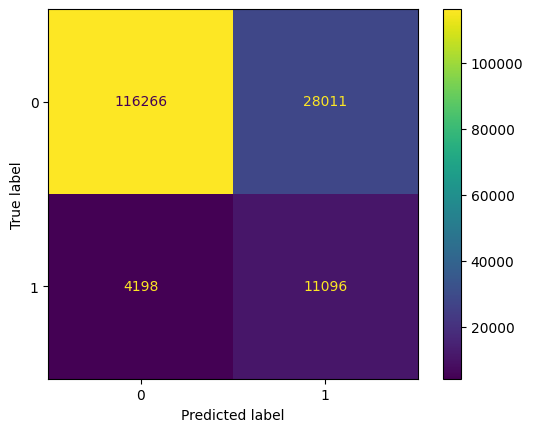

In [ ]:
cm = confusion_matrix(y_jigsaw, preds_jigsaw) #es amb el millor model aquest
ConfusionMatrixDisplay(cm).plot()

In [ ]:
print(df["label"].value_counts(normalize=True))
print(jigsaw["label"].value_counts(normalize=True))

label
1    0.832015
0    0.167985
Name: proportion, dtype: float64
label
0    0.904156
1    0.095844
Name: proportion, dtype: float64


In [ ]:
jigsaw["label"].value_counts()

,count
label,
0,144277
1,15294


## Canvi definició toxicitat

In [ ]:
y_jigsaw_all = jigsaw["label_all"]

print("RESULTATS JIGSAW — BAG OF WORDS")

for name, model in best_models_bow.items():

    preds = model.predict(X_jigsaw_bow)

    f1 = f1_score(y_jigsaw_all, preds, average="macro")

    print(name, "F1-macro:", f1)

RESULTATS JIGSAW — BAG OF WORDS
Logistic Regression F1-macro: 0.6591806831144418
Linear SVM F1-macro: 0.6500555156888281
Multinomial NB F1-macro: 0.6152812392034195
Complement NB F1-macro: 0.694251488476022
Bernoulli NB F1-macro: 0.6258938455159494


In [ ]:
model = best_models_bow["Linear SVM"]

preds_jigsaw_all = model.predict(X_jigsaw_bow)

f1 = f1_score(y_jigsaw_all, preds_jigsaw_all, average="macro")

print("F1 Jigsaw BOW (ALL labels):", f1)

F1 Jigsaw BOW (ALL labels): 0.6500555156888281


In [ ]:
y_jigsaw_all = jigsaw["label_all"]

print("RESULTATS JIGSAW — BAG OF WORDS")

for name, model in best_models_tfidf.items():

    preds = model.predict(X_jigsaw_tfidf)

    f1 = f1_score(y_jigsaw_all, preds, average="macro")

    print(name, "F1-macro:", f1)

RESULTATS JIGSAW — BAG OF WORDS
Logistic Regression F1-macro: 0.5072239703186368
Linear SVM F1-macro: 0.5370026585966821
Multinomial NB F1-macro: 0.38405263073201323
Complement NB F1-macro: 0.5931108729138006
Bernoulli NB F1-macro: 0.6258938455159494


In [ ]:
model = best_models_tfidf["Linear SVM"]

preds_jigsaw_all = model.predict(X_jigsaw_tfidf)

f1 = f1_score(y_jigsaw_all, preds_jigsaw_all, average="macro")

print("F1 Jigsaw TFIDF (ALL labels):", f1)

F1 Jigsaw TFIDF (ALL labels): 0.5370026585966821


#Millores

In [ ]:
# PRINCIPAL
print("F1 PRINCIPAL (WORD):",
      f1_score(y_test, preds_principal, average="macro"))

# JIGSAW
print("F1 Jigsaw (WORD):",
      f1_score(y_jigsaw, preds_jigsaw, average="macro"))

F1 PRINCIPAL (WORD): 0.9263452802539336
F1 Jigsaw (WORD): 0.6431356868888115


In [ ]:

def find_best_threshold_cv(model, X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    #thresholds = np.linspace(-1.5, 1.5, 15)
    thresholds = np.linspace(-2, 2, 50)
    best_threshold = 0
    best_f1 = 0

    for t in thresholds:
        f1_scores = []

        for train_idx, val_idx in skf.split(X, y):
            X_tr = X[train_idx, :]
            X_val = X[val_idx, :]
            y_tr = y.iloc[train_idx]
            y_val = y.iloc[val_idx]

            model.fit(X_tr, y_tr)

            scores_val = model.decision_function(X_val)
            preds_val = (scores_val >= t).astype(int)

            f1 = f1_score(y_val, preds_val, average="macro")
            f1_scores.append(f1)

        mean_f1 = np.mean(f1_scores)

        if mean_f1 > best_f1:
            best_f1 = mean_f1
            best_threshold = t

    return best_threshold, best_f1

In [ ]:
best_model = best_models_bow["Linear SVM"]

# Buscar el millor threshold
best_threshold, best_cv_f1 = find_best_threshold_cv(best_model, X_train_bow, y_train)

print("Best threshold (CV):", best_threshold)
print("Best CV F1 (WORD + threshold):", best_cv_f1)

best_model.fit(X_train_bow, y_train)

# TEST final
scores_test = best_model.decision_function(X_test_bow)
preds_test_thresh = (scores_test >= best_threshold).astype(int)

print("F1 PRINCIPAL (WORD + threshold):",
      f1_score(y_test, preds_test_thresh, average="macro"))

# JIGSAW final
scores_jigsaw = best_model.decision_function(X_jigsaw_bow)
preds_jigsaw_thresh = (scores_jigsaw >= best_threshold).astype(int)

print("F1 Jigsaw (WORD + threshold):",
      f1_score(y_jigsaw, preds_jigsaw_thresh, average="macro"))

Best threshold (CV): 0.12244897959183643
Best CV F1 (WORD + threshold): 0.9194295759701433
F1 PRINCIPAL (WORD + threshold): 0.9268757028142918
F1 Jigsaw (WORD + threshold): 0.6789541466650209


In [ ]:
char_vectorizer = CountVectorizer(
    analyzer="char",
    ngram_range=(3,5),
    min_df=5
)

X_train_char = char_vectorizer.fit_transform(X_train)
X_test_char = char_vectorizer.transform(X_test)

# MODEL
model_char = LinearSVC(C=best_models_bow["Linear SVM"].C)
model_char.fit(X_train_char, y_train)

# PRINCIPAL
preds_char = model_char.predict(X_test_char)
print("F1 PRINCIPAL (CHAR):",
      f1_score(y_test, preds_char, average="macro"))

# JIGSAW
X_jigsaw_char = char_vectorizer.transform(jigsaw["clean_text2"])
preds_jigsaw_char = model_char.predict(X_jigsaw_char)

print("F1 Jigsaw (CHAR):",
      f1_score(y_jigsaw, preds_jigsaw_char, average="macro"))

F1 PRINCIPAL (CHAR): 0.9148756216033687
F1 Jigsaw (CHAR): 0.6698368999680566


In [ ]:
X_train_combined = hstack([X_train_bow, X_train_char])
X_test_combined = hstack([X_test_bow, X_test_char])

model_combined = LinearSVC(C=best_models_bow["Linear SVM"].C,random_state=42)
model_combined.fit(X_train_combined, y_train)

# TEST
preds_combined = model_combined.predict(X_test_combined)
print("F1 PRINCIPAL (WORD + CHAR):",
      f1_score(y_test, preds_combined, average="macro"))

# JIGSAW
X_jigsaw_combined = hstack([X_jigsaw_bow, X_jigsaw_char])
preds_jigsaw_combined = model_combined.predict(X_jigsaw_combined)

print("F1 Jigsaw (WORD + CHAR):",
      f1_score(y_jigsaw, preds_jigsaw_combined, average="macro"))

F1 PRINCIPAL (WORD + CHAR): 0.9167818110722937
F1 Jigsaw (WORD + CHAR): 0.6721691788304205


In [ ]:
best_threshold_combined, best_cv_f1_combined = find_best_threshold_cv(
    model_combined,
    X_train_combined,
    y_train
)

print("Best threshold (COMBINED CV):", best_threshold_combined)
print("Best CV F1 (COMBINED):", best_cv_f1_combined)

model_combined.fit(X_train_combined, y_train)

scores_combined = model_combined.decision_function(X_test_combined)

preds_combined_thresh = (scores_combined >= best_threshold_combined).astype(int)

print("F1 PRINCIPAL (WORD + CHAR + threshold):",
      f1_score(y_test, preds_combined_thresh, average="macro"))

scores_jigsaw_combined = model_combined.decision_function(X_jigsaw_combined)

preds_jigsaw_combined_thresh = (scores_jigsaw_combined >= best_threshold_combined).astype(int)

print("F1 Jigsaw (WORD + CHAR + threshold):",
      f1_score(y_jigsaw, preds_jigsaw_combined_thresh, average="macro"))

Best threshold (COMBINED CV): 0.12244897959183643
Best CV F1 (COMBINED): 0.910092831137107
F1 PRINCIPAL (WORD + CHAR + threshold): 0.9222041527540246
F1 Jigsaw (WORD + CHAR + threshold): 0.6912609693111021


## RESULTATS MODEL FINAL

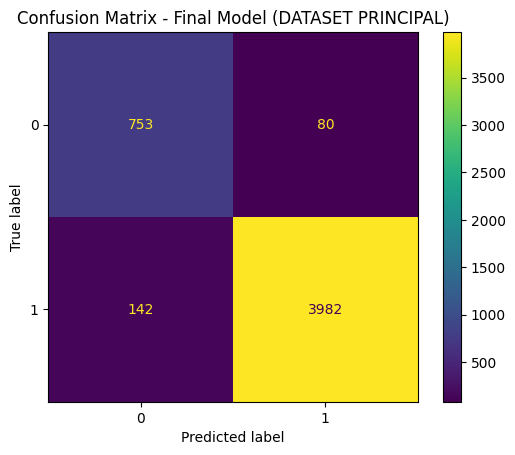

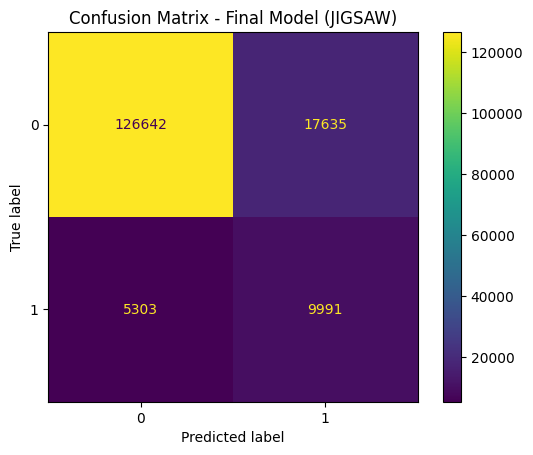

In [ ]:
# DATASET PRINCIPAL
cm_test = confusion_matrix(y_test, preds_combined_thresh)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp.plot()
plt.title("Confusion Matrix - Final Model (DATASET PRINCIPAL)")
plt.show()


# JIGSAW
cm_jigsaw = confusion_matrix(y_jigsaw, preds_jigsaw_combined_thresh)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_jigsaw)
disp.plot()
plt.title("Confusion Matrix - Final Model (JIGSAW)")
plt.show()

In [ ]:
print("=== CLASSIFICATION REPORT - PRINCIPAL ===")
print(classification_report(y_test, preds_combined_thresh))

print("\n=== CLASSIFICATION REPORT - JIGSAW ===")
print(classification_report(y_jigsaw, preds_jigsaw_combined_thresh))

=== CLASSIFICATION REPORT - PRINCIPAL ===
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       833
           1       0.98      0.97      0.97      4124

    accuracy                           0.96      4957
   macro avg       0.91      0.93      0.92      4957
weighted avg       0.96      0.96      0.96      4957


=== CLASSIFICATION REPORT - JIGSAW ===
              precision    recall  f1-score   support

           0       0.96      0.88      0.92    144277
           1       0.36      0.65      0.47     15294

    accuracy                           0.86    159571
   macro avg       0.66      0.77      0.69    159571
weighted avg       0.90      0.86      0.87    159571



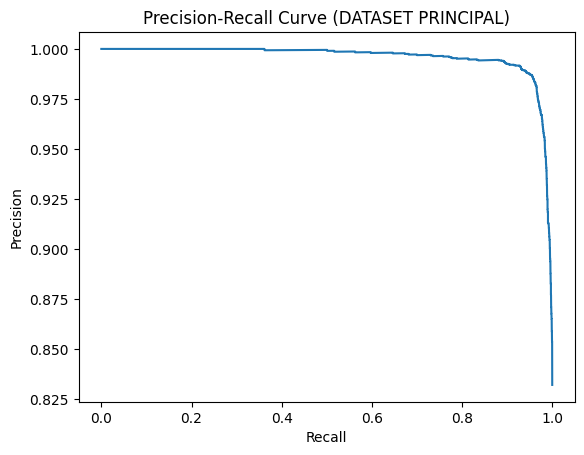

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, scores_combined)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (DATASET PRINCIPAL)")
plt.show()

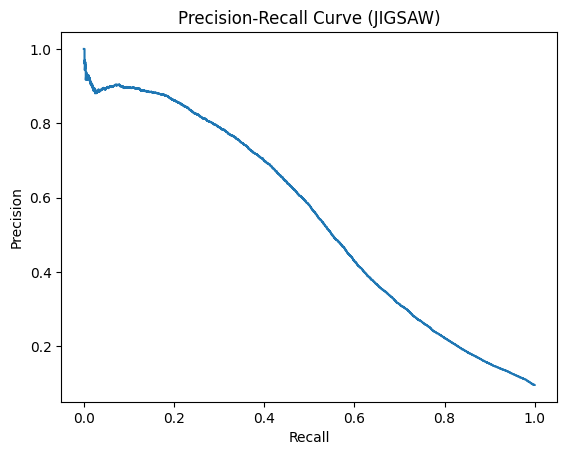

In [ ]:
precision_j, recall_j, _ = precision_recall_curve(y_jigsaw, scores_jigsaw_combined)

plt.figure()
plt.plot(recall_j, precision_j)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (JIGSAW)")
plt.show()

# Sense stopwords:

In [ ]:
def remove_stopwords(text):
    words = text.split()
    return " ".join([w for w in words if w.lower() not in ENGLISH_STOP_WORDS])

In [ ]:
# DATASET PRINCIPAL
X_train_ns_text = X_train.apply(remove_stopwords)
X_test_ns_text = X_test.apply(remove_stopwords)

# JIGSAW
X_jigsaw_ns_text = jigsaw["clean_text2"].apply(remove_stopwords)

In [ ]:
# WORD
bow_vectorizer_ns = CountVectorizer(
    ngram_range=(1,2),
    min_df=5
)

X_train_bow_ns = bow_vectorizer_ns.fit_transform(X_train_ns_text)
X_test_bow_ns = bow_vectorizer_ns.transform(X_test_ns_text)
X_jigsaw_bow_ns = bow_vectorizer_ns.transform(X_jigsaw_ns_text)

# CHAR (igual que abans)
X_train_char_ns = char_vectorizer.transform(X_train_ns_text)
X_test_char_ns = char_vectorizer.transform(X_test_ns_text)
X_jigsaw_char_ns = char_vectorizer.transform(X_jigsaw_ns_text)

In [ ]:
X_train_combined_ns = hstack([X_train_bow_ns, X_train_char_ns])
X_test_combined_ns = hstack([X_test_bow_ns, X_test_char_ns])
X_jigsaw_combined_ns = hstack([X_jigsaw_bow_ns, X_jigsaw_char_ns])

In [ ]:
model_ns = LinearSVC(C=best_models_bow["Linear SVM"].C)

best_threshold_ns, best_cv_f1_ns = find_best_threshold_cv(
    model_ns,
    X_train_combined_ns,
    y_train
)

print("Best threshold (NO STOPWORDS):", best_threshold_ns)

model_ns.fit(X_train_combined_ns, y_train)

Best threshold (NO STOPWORDS): 0.204081632653061


LinearSVC(C=0.1)

In [ ]:
scores_test_ns = model_ns.decision_function(X_test_combined_ns)
preds_test_ns = (scores_test_ns >= best_threshold_ns).astype(int)

print("F1 TEST (sense stopwords):",
      f1_score(y_test, preds_test_ns, average="macro"))

F1 TEST (sense stopwords): 0.9172005715697393


In [ ]:
scores_jigsaw_ns = model_ns.decision_function(X_jigsaw_combined_ns)
preds_jigsaw_ns = (scores_jigsaw_ns >= best_threshold_ns).astype(int)

print("F1 JIGSAW (sense stopwords):",
      f1_score(y_jigsaw, preds_jigsaw_ns, average="macro"))

F1 JIGSAW (sense stopwords): 0.7241847246110218


In [ ]:
print("\n--- COMPARACIÓ FINAL ---")

print("MODEL ORIGINAL:")
print("F1 TEST:", f1_score(y_test, preds_combined_thresh, average="macro"))
print("F1 JIGSAW:", f1_score(y_jigsaw, preds_jigsaw_combined_thresh, average="macro"))

print("\nSENSE STOPWORDS:")
print("F1 TEST:", f1_score(y_test, preds_test_ns, average="macro"))
print("F1 JIGSAW:", f1_score(y_jigsaw, preds_jigsaw_ns, average="macro"))


--- COMPARACIÓ FINAL ---
MODEL ORIGINAL:
F1 TEST: 0.9222041527540246
F1 JIGSAW: 0.6912609693111021

SENSE STOPWORDS:
F1 TEST: 0.9172005715697393
F1 JIGSAW: 0.7241847246110218


In [ ]:
#eliminem per a que no ocupi memoria:
del X_train_bow_ns, X_test_bow_ns, X_jigsaw_bow_ns
del X_train_char_ns, X_test_char_ns, X_jigsaw_char_ns
del X_train_combined_ns, X_test_combined_ns, X_jigsaw_combined_ns
del preds_test_ns, preds_jigsaw_ns

import gc
gc.collect()

7465

# Experiment d’adaptació amb 10% de Jigsaw

In [ ]:
# Text i labels
X_jigsaw_text = jigsaw["clean_text2"]
y_jigsaw = jigsaw["label"]

# Split 10% adaptació
X_jig_adapt_10, X_jig_eval_10, y_jig_adapt_10, y_jig_eval_10 = train_test_split(
    X_jigsaw_text,
    y_jigsaw,
    test_size=0.90,
    stratify=y_jigsaw,
    random_state=42
)

In [ ]:
# ADAPTACIÓ 10% — BASELINE (WORD)

# Combinar dades
X_train_adapt_10 = pd.concat([X_train, X_jig_adapt_10])
y_train_adapt_10 = pd.concat([y_train, y_jig_adapt_10])

# RE-FIT vectoritzador WORD
bow_vectorizer_10 = CountVectorizer(
    ngram_range=(1,2),
    min_df=5
)

X_train_bow_10 = bow_vectorizer_10.fit_transform(X_train_adapt_10)
X_test_bow_10 = bow_vectorizer_10.transform(X_test)
X_jig_bow_10 = bow_vectorizer_10.transform(X_jig_eval_10)

# Model baseline
model_10_baseline = LinearSVC(
    C=best_models_bow["Linear SVM"].C,
    max_iter=5000
)

model_10_baseline.fit(X_train_bow_10, y_train_adapt_10)

# RESULTATS

# PRINCIPAL
scores_test_10 = model_10_baseline.decision_function(X_test_bow_10)
preds_test_10 = (scores_test_10 >= best_threshold).astype(int)

# JIGSAW
scores_jig_10 = model_10_baseline.decision_function(X_jig_bow_10)
preds_jig_10 = (scores_jig_10 >= best_threshold).astype(int)

print("=== ADAPTACIÓ 10% — BASELINE (WORD) ===")
print("F1 TEST:", f1_score(y_test, preds_test_10, average="macro"))
print("F1 Jigsaw:", f1_score(y_jig_eval_10, preds_jig_10, average="macro"))

=== ADAPTACIÓ 10% — BASELINE (WORD) ===
F1 TEST: 0.9313550188852455
F1 Jigsaw: 0.8346271965559813


In [ ]:
del X_train_bow_10, X_test_bow_10, X_jig_bow_10
del scores_test_10, scores_jig_10
del preds_test_10, preds_jig_10
del model_10_baseline
del bow_vectorizer_10

import gc
gc.collect()

0

In [ ]:
#  ADAPTACIÓ 10% — MODEL FINAL

# Combinar dades
X_train_adapt_10 = pd.concat([X_train, X_jig_adapt_10])
y_train_adapt_10 = pd.concat([y_train, y_jig_adapt_10])

# RE-FIT vectoritzadors

# WORD
bow_vectorizer_10 = CountVectorizer(
    ngram_range=(1,2),
    min_df=5
)

X_word_train = bow_vectorizer_10.fit_transform(X_train_adapt_10)
X_word_test = bow_vectorizer_10.transform(X_test)
X_word_jig = bow_vectorizer_10.transform(X_jig_eval_10)

# CHAR
char_vectorizer_10 = CountVectorizer(
    analyzer="char",
    ngram_range=(3,5),
    min_df=5
)

X_char_train = char_vectorizer_10.fit_transform(X_train_adapt_10)
X_char_test = char_vectorizer_10.transform(X_test)
X_char_jig = char_vectorizer_10.transform(X_jig_eval_10)

# COMBINAR
X_train_combined_10 = hstack([X_word_train, X_char_train])
X_test_combined_10 = hstack([X_word_test, X_char_test])
X_jig_combined_10 = hstack([X_word_jig, X_char_jig])

# MODEL FINAL
model_10_final = LinearSVC(
    C=best_models_bow["Linear SVM"].C,
    max_iter=5000
)

model_10_final.fit(X_train_combined_10, y_train_adapt_10)

# RESULTATS

# TEST
scores_test_10 = model_10_final.decision_function(X_test_combined_10)
preds_test_10 = (scores_test_10 >= best_threshold_combined).astype(int)
# JIGSAW
scores_jig_10 = model_10_final.decision_function(X_jig_combined_10)
preds_jig_10 = (scores_jig_10 >= best_threshold_combined).astype(int)

print("=== ADAPTACIÓ 10% — MODEL FINAL ===")
print("F1 TEST:", f1_score(y_test, preds_test_10, average="macro"))
print("F1 Jigsaw:", f1_score(y_jig_eval_10, preds_jig_10, average="macro"))

=== ADAPTACIÓ 10% — MODEL FINAL ===
F1 TEST: 0.9252556186188259
F1 Jigsaw: 0.8366824593869244


In [ ]:
# NETEJA RAM
del X_word_train, X_word_test, X_word_jig
del X_char_train, X_char_test, X_char_jig
del X_train_combined_10, X_test_combined_10, X_jig_combined_10

del scores_test_10, scores_jig_10
del preds_test_10, preds_jig_10

del model_10_final
del bow_vectorizer_10, char_vectorizer_10

import gc
gc.collect()

0

# Anàliisi qualitativa



##Analisi n-grams

In [ ]:
pd.set_option("display.max_colwidth", None)

# TOP N-GRAMS DEL MODEL FINAL

feature_names_word = bow_vectorizer.get_feature_names_out()
feature_names_char = char_vectorizer.get_feature_names_out()

n_word_features = len(feature_names_word)
coefs = model_combined.coef_[0]

coefs_word = coefs[:n_word_features]
coefs_char = coefs[n_word_features:]

# TOP WORD N-GRAMS TÒXICS
top_word_idx = np.argsort(coefs_word)[-20:]

print("=== TOP WORD N-GRAMS TÒXICS ===")
for i in reversed(top_word_idx):
    print(feature_names_word[i], round(coefs_word[i], 4))

=== TOP WORD N-GRAMS TÒXICS ===
fag 0.4561
hoe 0.3406
ass 0.2679
hoes 0.2501
shit 0.2469
bitch 0.2159
cunt 0.2122
fuck 0.1919
trash though 0.1871
nig 0.1862
white trash 0.1666
negro 0.163
pussy 0.161
wtf 0.1496
fags 0.1489
he trash 0.1414
coons 0.1389
dyke 0.1379
re trash 0.1374
stfu 0.131


In [ ]:
# TOP WORD N-GRAMS NO TÒXICS
top_word_idx_clean = np.argsort(coefs_word)[:20]

print("\n=== TOP WORD N-GRAMS NO TÒXICS ===")
for i in top_word_idx_clean:
    print(feature_names_word[i], round(coefs_word[i], 4))



=== TOP WORD N-GRAMS NO TÒXICS ===
hoe hoe -0.2396
night -0.1508
hmu -0.1342
trash -0.1213
hi ho -0.1112
via -0.1073
hoe rt -0.1059
shy -0.1052
rt why -0.1028
my nips -0.1018
slap hoe -0.0978
slap -0.0954
el -0.0932
the trash -0.0912
crackers -0.0911
like it -0.0908
hoes and -0.0892
is that -0.0864
charlie -0.086
negros -0.085


In [ ]:
# TOP CHAR N-GRAMS TÒXICS
top_char_idx = np.argsort(coefs_char)[-20:]

print("\n=== TOP CHAR N-GRAMS TÒXICS ===")
for i in reversed(top_char_idx):
    print(feature_names_char[i], round(coefs_char[i], 4))



=== TOP CHAR N-GRAMS TÒXICS ===
fag 0.7008
hoe 0.497
fuck 0.3418
fuc 0.335
bitch 0.3208
bitc 0.3208
hit 0.2941
nig 0.2907
cunt 0.2844
cun 0.2844
 ho 0.2708
nigg 0.2676
shit 0.2669
 ni 0.2664
puss 0.2628
igg 0.2586
 nig 0.258
 ass 0.2544
itch 0.2513
 hoe 0.2474


In [ ]:
# TOP CHAR N-GRAMS NO TÒXICS
top_char_idx_clean = np.argsort(coefs_char)[:20]

print("\n=== TOP CHAR N-GRAMS NO TÒXICS ===")
for i in top_char_idx_clean:
    print(feature_names_char[i], round(coefs_char[i], 4))


=== TOP CHAR N-GRAMS NO TÒXICS ===
oe ho -0.2054
hoe h -0.1895
oe h -0.1895
o tho -0.184
el  -0.1819
red  -0.1695
s mo -0.1692
"neve -0.1689
"nev -0.1689
-ho -0.1689
"ne -0.1643
rd" -0.1611
 la -0.1574
ard" -0.1566
ird -0.1555
oes a -0.1547
e,  -0.1528
cker  -0.1516
en  -0.1507
ss m -0.1499


## Anàlisi dataset principal (FP i FN)


In [ ]:
df_test = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "label": y_test.reset_index(drop=True),
    "pred": preds_combined_thresh
})

fp_test = df_test[(df_test["label"] == 0) & (df_test["pred"] == 1)].copy()
fn_test = df_test[(df_test["label"] == 1) & (df_test["pred"] == 0)].copy()

print("=== FALSE POSITIVES DATASET PRINCIPAL ===")
display(fp_test.sample(4, random_state=42))

print("=== FALSE NEGATIVES DATASET PRINCIPAL ===")
display(fn_test.sample(4, random_state=42))

=== FALSE POSITIVES DATASET PRINCIPAL ===


,text,label,pred
1718,You realize I’m going to have to get out all those horror and other poems I wrote abo…,0,1
13,But rich is a light skin coon. So it's expected.,0,1
1581,Remember Dad running a rotary hoe over corn after a freeze to knock the dead leaves off after they turn brown,0,1
1799,Ho ho ho.,0,1


=== FALSE NEGATIVES DATASET PRINCIPAL ===


,text,label,pred
4518,im weeaboo trash,1,0
853,"Bij vraag wat is d naam van de engels des doods,dacht eerst Robert.Ik:Israel..uhm iets met Gargamel,hoe heet die kat ook al weer..oja Azrael",1,0
2863,"Ja zo denkt ieder wel 't zijne over zaken he. je mag mij noemen hoe je wilt, ben namelijk erg voor vrijheid van meningsuiting.",1,0
3153,"a girl tweeted ""you might be ghetto if u bring food from outside into the movies"" no u might be stupid if u pay 4.99 …",1,0


In [ ]:
def explain_text_word(text, vectorizer, coefs_word, top_n=8):
    x = vectorizer.transform([text])
    indices = x.indices
    values = x.data

    contributions = []
    for idx, val in zip(indices, values):
        ngram = vectorizer.get_feature_names_out()[idx]
        coef = coefs_word[idx]
        contrib = val * coef
        contributions.append((ngram, coef, contrib))

    contributions = sorted(contributions, key=lambda x: x[2], reverse=True)

    top_toxic = [c for c in contributions if c[2] > 0][:top_n]
    top_nontoxic = sorted([c for c in contributions if c[2] < 0], key=lambda x: x[2])[:top_n]

    return top_toxic, top_nontoxic

In [ ]:
# MICRO-CASOS DEL DATASET PRINCIPAL

sample_fp_test = fp_test.sample(4, random_state=42)
sample_fn_test = fn_test.sample(4, random_state=42)

print("#############################")
print("MICRO-CASOS: FALSE POSITIVES")
print("#############################")

for _, row in sample_fp_test.iterrows():
    text = row["text"]
    top_toxic, top_nontoxic = explain_text_word(text, bow_vectorizer, coefs_word, top_n=6)

    print("\n-----------------------------------")
    print("TEXT:", text)
    print("LABEL REAL:", row["label"])
    print("PRED:", row["pred"])

    print("\nN-grams que empenyen cap a TÒXIC:")
    for ngram, coef, contrib in top_toxic:
        print(f"{ngram:25s} coef={coef:.4f} contrib={contrib:.4f}")

    print("\nN-grams que empenyen cap a NO TÒXIC:")
    for ngram, coef, contrib in top_nontoxic:
        print(f"{ngram:25s} coef={coef:.4f} contrib={contrib:.4f}")

#############################
MICRO-CASOS: FALSE POSITIVES
#############################

-----------------------------------
TEXT: You realize I’m going to have to get out all those horror and other poems I wrote abo…
LABEL REAL: 0
PRED: 1

N-grams que empenyen cap a TÒXIC:
you                       coef=0.1276 contrib=0.1276
all                       coef=0.0339 contrib=0.0339
you realize               coef=0.0295 contrib=0.0295
to                        coef=0.0143 contrib=0.0287
wrote                     coef=0.0248 contrib=0.0248
get out                   coef=0.0232 contrib=0.0232

N-grams que empenyen cap a NO TÒXIC:
out                       coef=-0.0613 contrib=-0.0613
abo                       coef=-0.0496 contrib=-0.0496
other                     coef=-0.0473 contrib=-0.0473
going to                  coef=-0.0348 contrib=-0.0348
and                       coef=-0.0234 contrib=-0.0234
get                       coef=-0.0126 contrib=-0.0126

-----------------------------------
T

In [ ]:
print("\n\n#############################")
print("MICRO-CASOS: FALSE NEGATIVES")
print("#############################")

for _, row in sample_fn_test.iterrows():
    text = row["text"]
    top_toxic, top_nontoxic = explain_text_word(text, bow_vectorizer, coefs_word, top_n=6)

    print("\n-----------------------------------")
    print("TEXT:", text)
    print("LABEL REAL:", row["label"])
    print("PRED:", row["pred"])

    print("\nN-grams que empenyen cap a TÒXIC:")
    for ngram, coef, contrib in top_toxic:
        print(f"{ngram:25s} coef={coef:.4f} contrib={contrib:.4f}")

    print("\nN-grams que empenyen cap a NO TÒXIC:")
    for ngram, coef, contrib in top_nontoxic:
        print(f"{ngram:25s} coef={coef:.4f} contrib={contrib:.4f}")



#############################
MICRO-CASOS: FALSE NEGATIVES
#############################

-----------------------------------
TEXT: im weeaboo trash
LABEL REAL: 1
PRED: 0

N-grams que empenyen cap a TÒXIC:

N-grams que empenyen cap a NO TÒXIC:
trash                     coef=-0.1213 contrib=-0.1213
im                        coef=-0.0760 contrib=-0.0760

-----------------------------------
TEXT: Bij vraag wat is d naam van de engels des doods,dacht eerst Robert.Ik:Israel..uhm iets met Gargamel,hoe heet die kat ook al weer..oja Azrael
LABEL REAL: 1
PRED: 0

N-grams que empenyen cap a TÒXIC:
hoe                       coef=0.3406 contrib=0.3406
israel                    coef=0.0288 contrib=0.0288
wat                       coef=0.0190 contrib=0.0190
de                        coef=0.0158 contrib=0.0158
is                        coef=0.0124 contrib=0.0124
des                       coef=0.0102 contrib=0.0102

N-grams que empenyen cap a NO TÒXIC:
ik                        coef=-0.0351 contrib=

## Anàlisi datatset jigsaw (FP i FN)

In [ ]:
jigsaw_eval = jigsaw.copy()
jigsaw_eval["pred"] = preds_jigsaw_combined_thresh

fp_jigsaw = jigsaw_eval[(jigsaw_eval["label"] == 0) & (jigsaw_eval["pred"] == 1)].copy()
fn_jigsaw = jigsaw_eval[(jigsaw_eval["label"] == 1) & (jigsaw_eval["pred"] == 0)].copy()

print("=== FALSE POSITIVES JIGSAW ===")
display(fp_jigsaw[["clean_text2", "label", "pred"]].sample(4, random_state=42))

print("=== FALSE NEGATIVES JIGSAW ===")
display(fn_jigsaw[["clean_text2", "label", "pred"]].sample(4, random_state=42))

=== FALSE POSITIVES JIGSAW ===


,clean_text2,label,pred
140073,"No, you're incorrect. Kww and I is the correct way. -",0,1
42532,"Argh, I just discovered that you copied Trans-Mississippi Exposition from even though they have big copyright notices all over the site. That is a big no-no - I'm going to have to delete the copied material. 06:08, 17 Jul 2004",0,1
42080,"I just want to resolve this issue. Can you stop blocking me with robots (just look at my talk page). This is original content, in breach of the copyright law. Give me a phone number or an email address, or at least an on-line way to find someone who can deal with this.",0,1
121210,"I believe that you have erred in the interpretation of wikipedia policy and rights, I am contacting authorities for your non-consented use of my signature in your discussion page.",0,1


=== FALSE NEGATIVES JIGSAW ===


,clean_text2,label,pred
15719,"RE: """"and he picked his nose too!!"""" What are you, some kind of Klansman? Taney was a racist douchebag and he's probably burning in Hell. Any and all negative aspersions towards him should be in bold print, along with Photoshopped pictures of him engaging in fellatio with a Rottweiler.""",1,0
104474,UD is now about Homewrecking Sluts Karen Nussle did accept money from that prostitutional family. I'm a TULIP boy. UD is now on the Dark Side. I would like to save UD,1,0
93503,THE GUY ABOVE ME IS A WANKER!!,1,0
69596,"Are you really going to let that guy walk away scout free, because he's an admin, and block me because I was concerned about a conflict of interest? I want to take this up with ARBCOM. This is ridiculous.",1,0


In [ ]:
#  MICRO-CASOS DE JIGSAW

sample_fp_jigsaw = fp_jigsaw.sample(4, random_state=42)
sample_fn_jigsaw = fn_jigsaw.sample(4, random_state=42)

print("#############################")
print("MICRO-CASOS JIGSAW: FALSE POSITIVES")
print("#############################")

for _, row in sample_fp_jigsaw.iterrows():
    text = row["clean_text2"]
    top_toxic, top_nontoxic = explain_text_word(text, bow_vectorizer, coefs_word, top_n=6)

    print("\n-----------------------------------")
    print("TEXT:", text)
    print("LABEL REAL:", row["label"])
    print("PRED:", row["pred"])

    print("\nN-grams que empenyen cap a TÒXIC:")
    for ngram, coef, contrib in top_toxic:
        print(f"{ngram:25s} coef={coef:.4f} contrib={contrib:.4f}")

    print("\nN-grams que empenyen cap a NO TÒXIC:")
    for ngram, coef, contrib in top_nontoxic:
        print(f"{ngram:25s} coef={coef:.4f} contrib={contrib:.4f}")



#############################
MICRO-CASOS JIGSAW: FALSE POSITIVES
#############################

-----------------------------------
TEXT: No, you're incorrect. Kww and I is the correct way. -
LABEL REAL: 0
PRED: 1

N-grams que empenyen cap a TÒXIC:
you                       coef=0.1276 contrib=0.1276
way                       coef=0.0682 contrib=0.0682
no                        coef=0.0447 contrib=0.0447
is the                    coef=0.0242 contrib=0.0242
you re                    coef=0.0133 contrib=0.0133
is                        coef=0.0124 contrib=0.0124

N-grams que empenyen cap a NO TÒXIC:
and                       coef=-0.0234 contrib=-0.0234
no you                    coef=-0.0152 contrib=-0.0152
the                       coef=-0.0137 contrib=-0.0137
correct                   coef=-0.0102 contrib=-0.0102

-----------------------------------
TEXT: Argh, I just discovered that you copied Trans-Mississippi Exposition from even though they have big copyright notices all over the 

In [ ]:
print("\n\n#############################")
print("MICRO-CASOS JIGSAW: FALSE NEGATIVES")
print("#############################")

for _, row in sample_fn_jigsaw.iterrows():
    text = row["clean_text2"]
    top_toxic, top_nontoxic = explain_text_word(text, bow_vectorizer, coefs_word, top_n=6)

    print("\n-----------------------------------")
    print("TEXT:", text)
    print("LABEL REAL:", row["label"])
    print("PRED:", row["pred"])

    print("\nN-grams que empenyen cap a TÒXIC:")
    for ngram, coef, contrib in top_toxic:
        print(f"{ngram:25s} coef={coef:.4f} contrib={contrib:.4f}")

    print("\nN-grams que empenyen cap a NO TÒXIC:")
    for ngram, coef, contrib in top_nontoxic:
        print(f"{ngram:25s} coef={coef:.4f} contrib={contrib:.4f}")



#############################
MICRO-CASOS JIGSAW: FALSE NEGATIVES
#############################

-----------------------------------
TEXT: RE: ""and he picked his nose too!!"" What are you, some kind of Klansman? Taney was a racist douchebag and he's probably burning in Hell. Any and all negative aspersions towards him should be in bold print, along with Photoshopped pictures of him engaging in fellatio with a Rottweiler."
LABEL REAL: 1
PRED: 0

N-grams que empenyen cap a TÒXIC:
he                        coef=0.0826 contrib=0.1651
him                       coef=0.0657 contrib=0.1313
you                       coef=0.1276 contrib=0.1276
hell                      coef=0.0817 contrib=0.0817
racist                    coef=0.0489 contrib=0.0489
in                        coef=0.0155 contrib=0.0464

N-grams que empenyen cap a NO TÒXIC:
and                       coef=-0.0234 contrib=-0.0702
are you                   coef=-0.0586 contrib=-0.0586
and he                    coef=-0.0279 contrib=-

In [ ]:
# TAULA RESUM DE MICRO-CASOS

def build_microcases_table(df_errors, text_col, label_col="label", pred_col="pred", n_cases=4, random_state=42):
    sample_df = df_errors.sample(n_cases, random_state=random_state).copy()
    rows = []

    for _, row in sample_df.iterrows():
        text = row[text_col]
        top_toxic, top_nontoxic = explain_text_word(text, bow_vectorizer, coefs_word, top_n=4)

        rows.append({
            "text": text,
            "label_real": row[label_col],
            "pred": row[pred_col],
            "ngrams_toxic": ", ".join([x[0] for x in top_toxic]) if top_toxic else "-",
            "ngrams_no_toxic": ", ".join([x[0] for x in top_nontoxic]) if top_nontoxic else "-"
        })

    return pd.DataFrame(rows)

microcases_fp_test = build_microcases_table(fp_test, text_col="text", n_cases=4, random_state=42)
microcases_fn_test = build_microcases_table(fn_test, text_col="text", n_cases=4, random_state=42)

microcases_fp_jigsaw = build_microcases_table(fp_jigsaw, text_col="clean_text2", n_cases=4, random_state=42)
microcases_fn_jigsaw = build_microcases_table(fn_jigsaw, text_col="clean_text2", n_cases=4, random_state=42)

print("=== FP TEST ===")
display(microcases_fp_test)

print("=== FN TEST ===")
display(microcases_fn_test)

print("=== FP JIGSAW ===")
display(microcases_fp_jigsaw)

print("=== FN JIGSAW ===")
display(microcases_fn_jigsaw)

=== FP TEST ===


,text,label_real,pred,ngrams_toxic,ngrams_no_toxic
0,You realize I’m going to have to get out all those horror and other poems I wrote abo…,0,1,"you, all, you realize, to","out, abo, other, going to"
1,But rich is a light skin coon. So it's expected.,0,1,"so, coon, light, is","but, it, rich"
2,Remember Dad running a rotary hoe over corn after a freeze to knock the dead leaves off after they turn brown,0,1,"hoe, turn, they, over","after, knock, leaves, the"
3,Ho ho ho.,0,1,ho,-


=== FN TEST ===


,text,label_real,pred,ngrams_toxic,ngrams_no_toxic
0,im weeaboo trash,1,0,-,"trash, im"
1,"Bij vraag wat is d naam van de engels des doods,dacht eerst Robert.Ik:Israel..uhm iets met Gargamel,hoe heet die kat ook al weer..oja Azrael",1,0,"hoe, israel, wat, de","ik, met, al, van"
2,"Ja zo denkt ieder wel 't zijne over zaken he. je mag mij noemen hoe je wilt, ben namelijk erg voor vrijheid van meningsuiting.",1,0,"hoe, he, over",van
3,"a girl tweeted ""you might be ghetto if u bring food from outside into the movies"" no u might be stupid if u pay 4.99 …",1,0,"you, no, be, might","if, be ghetto, might be, into"


=== FP JIGSAW ===


,text,label_real,pred,ngrams_toxic,ngrams_no_toxic
0,"No, you're incorrect. Kww and I is the correct way. -",0,1,"you, way, no, is the","and, no you, the, correct"
1,"Argh, I just discovered that you copied Trans-Mississippi Exposition from even though they have big copyright notices all over the site. That is a big no-no - I'm going to have to delete the copied material. 06:08, 17 Jul 2004",0,1,"you, no, they, that you","big, that, going to, though"
2,"I just want to resolve this issue. Can you stop blocking me with robots (just look at my talk page). This is original content, in breach of the copyright law. Give me a phone number or an email address, or at least an on-line way to find someone who can deal with this.",0,1,"an, you, me, way","or, at, of the, this"
3,"I believe that you have erred in the interpretation of wikipedia policy and rights, I am contacting authorities for your non-consented use of my signature in your discussion page.",0,1,"you, that you, in, your","you have, and, that, the"


=== FN JIGSAW ===


,text,label_real,pred,ngrams_toxic,ngrams_no_toxic
0,"RE: """"and he picked his nose too!!"""" What are you, some kind of Klansman? Taney was a racist douchebag and he's probably burning in Hell. Any and all negative aspersions towards him should be in bold print, along with Photoshopped pictures of him engaging in fellatio with a Rottweiler.""",1,0,"he, him, you, hell","and, are you, and he, along"
1,UD is now about Homewrecking Sluts Karen Nussle did accept money from that prostitutional family. I'm a TULIP boy. UD is now on the Dark Side. I would like to save UD,1,0,"is, about, on the, to","side, now, did, like to"
2,THE GUY ABOVE ME IS A WANKER!!,1,0,"me, guy, me is, is","the, the guy"
3,"Are you really going to let that guy walk away scout free, because he's an admin, and block me because I was concerned about a conflict of interest? I want to take this up with ARBCOM. This is ridiculous.",1,0,"you, he, an, me","are you, was, away, let"


# SARCASME

## Primer conjunt prova d'estrès

In [ ]:
sarcasm = pd.read_csv("/content/drive/MyDrive/TFG/train-balanced-sarcasm.csv")
sarcasm.head()

,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
0,0,NC and NH.,Trumpbart,politics,2,-1,-1,2016-10,2016-10-16 23:55:23,"Yeah, I get that argument. At this point, I'd prefer is she lived in NC as well."
1,0,You do know west teams play against west teams more than east teams right?,Shbshb906,nba,-4,-1,-1,2016-11,2016-11-01 00:24:10,The blazers and Mavericks (The wests 5 and 6 seed) did not even carry a good enough record to make the playoffs in the east last year.
2,0,"They were underdogs earlier today, but since Gronk's announcement this afternoon, the Vegas line has moved to patriots -1",Creepeth,nfl,3,3,0,2016-09,2016-09-22 21:45:37,They're favored to win.
3,0,"This meme isn't funny none of the ""new york nigga"" ones are.",icebrotha,BlackPeopleTwitter,-8,-1,-1,2016-10,2016-10-18 21:03:47,deadass don't kill my buzz
4,0,I could use one of those tools.,cush2push,MaddenUltimateTeam,6,-1,-1,2016-12,2016-12-30 17:00:13,Yep can confirm I saw the tool they use for that. It was made by our boy EASports_MUT


In [ ]:
sarcasm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010826 entries, 0 to 1010825
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   label           1010826 non-null  int64 
 1   comment         1010771 non-null  object
 2   author          1010826 non-null  object
 3   subreddit       1010826 non-null  object
 4   score           1010826 non-null  int64 
 5   ups             1010826 non-null  int64 
 6   downs           1010826 non-null  int64 
 7   date            1010826 non-null  object
 8   created_utc     1010826 non-null  object
 9   parent_comment  1010826 non-null  object
dtypes: int64(4), object(6)
memory usage: 77.1+ MB


In [ ]:
sarcasm = sarcasm.dropna(subset=["comment"])
sarcasm["clean_text"] = sarcasm["comment"].apply(cleaning_text)

In [ ]:
# TRANSFORMAR FEATURES
X_sarcasm_bow = bow_vectorizer.transform(sarcasm["clean_text"])
X_sarcasm_char = char_vectorizer.transform(sarcasm["clean_text"])
X_sarcasm_combined = hstack([X_sarcasm_bow, X_sarcasm_char])

In [ ]:
# PREDICCIONS MODEL FINAL
scores_sarcasm = model_combined.decision_function(X_sarcasm_combined)
preds_sarcasm = (scores_sarcasm >= best_threshold_combined).astype(int)

sarcasm_eval = sarcasm.copy()
sarcasm_eval["pred"] = preds_sarcasm

In [ ]:
# Percentatge global de textos marcats com tòxics
toxic_rate_total = sarcasm_eval["pred"].mean()

print("Toxic prediction rate (TOTAL):", toxic_rate_total)

Toxic prediction rate (TOTAL): 0.18186414133369477


In [ ]:
sarcastic = sarcasm_eval[sarcasm_eval["label"] == 1]
non_sarcastic = sarcasm_eval[sarcasm_eval["label"] == 0]

# Toxic prediction rate per grup
toxic_rate_sarc = sarcastic["pred"].mean()
toxic_rate_non_sarc = non_sarcastic["pred"].mean()

print("Toxic rate (sarcasm):", toxic_rate_sarc)
print("Toxic rate (non-sarcasm):", toxic_rate_non_sarc)

Toxic rate (sarcasm): 0.19717512782764243
Toxic rate (non-sarcasm): 0.16655421515107746


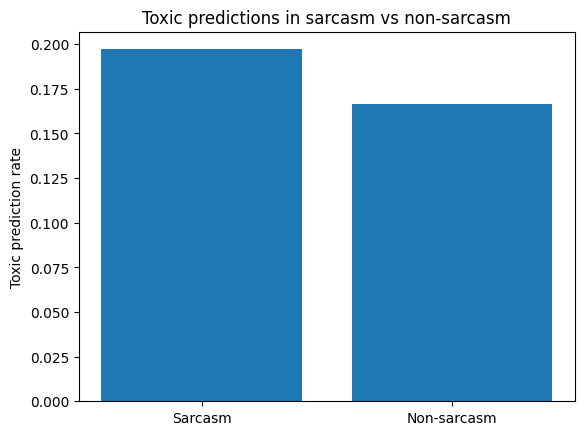

In [ ]:
labels = ["Sarcasm", "Non-sarcasm"]
values = [toxic_rate_sarc, toxic_rate_non_sarc]

plt.figure()
plt.bar(labels, values)
plt.ylabel("Toxic prediction rate")
plt.title("Toxic predictions in sarcasm vs non-sarcasm")
plt.show()

In [ ]:
# Sarcasmes classificats com tòxics (els "FP conceptuals")
fp_sarcasm = sarcastic[sarcastic["pred"] == 1]

pd.set_option('display.max_colwidth', None)

print("EXEMPLES DE SARCASME CLASSIFICAT COM TÒXIC:")
samples = fp_sarcasm["clean_text"].sample(25, random_state=42)

for i, text in enumerate(samples):
    print(f"\n[{i+1}] {text}")

EXEMPLES DE SARCASME CLASSIFICAT COM TÒXIC:

[1] White Nail being added to QBB: Confirmed.

[2] Sir, you forgot your

[3] Fuck you too!

[4] Do i look like i give a shit granny?

[5] Alright that's it, I'm changing my name so I don't have the same one as him

[6] Shit I had *excellent* credit when I was an 18 year old dumb ass, Gunny.

[7] That's about the percentage of all white men in America still voting.

[8] I'm sure it was a white guy

[9] Yeah because literally every single person who thinks Trump is the right man for the job over Hillary is retarded, right?

[10] Same place they got the gopro cameras... America

[11] They're not white supremacists, they're *white nativists* which is totally different, you know.

[12] Superiority is owning an Xbox One, a Playstation 4, a Wii U, a PlayStation Vita, a Nintendo 3DS XL, a $2000 Alienware prebuild and both the last iPhone and iPad, didn't you even know something that obvious?

[13] Wait til they start posting child porn again!

[14] 

In [ ]:
fp_words = Counter(" ".join(fp_sarcasm["clean_text"]).split())

print("Paraules més freqüents en sarcasme classificat com tòxic:")
print(fp_words.most_common(20))

Paraules més freqüents en sarcasme classificat com tòxic:
[('the', 36010), ('a', 28073), ('to', 28059), ('you', 21244), ('and', 17133), ('is', 16233), ('of', 15577), ('that', 12554), ('I', 12545), ('in', 11186), ('it', 8914), ('are', 8393), ('have', 8215), ('they', 7737), ('for', 7701), ('your', 7585), ('all', 7090), ('be', 6991), ('so', 6611), ('with', 6588)]


In [ ]:
# Comentaris NO sarcàstics classificats com tòxics
non_sarc_toxic = sarcasm_eval[
    (sarcasm_eval["label"] == 0) &
    (sarcasm_eval["pred"] == 1)
]

print("Nombre d'exemples:", len(non_sarc_toxic))

# Exemples
samples = non_sarc_toxic["clean_text"].sample(25, random_state=42)

for i, text in enumerate(samples):
    print(f"\n[{i+1}] {text}")

Nombre d'exemples: 84177

[1] At least I can read fuckface

[2] (((triggered)))

[3] Visa-free travel is also an important step forward, as Ukrainians will finally feel like normal people, because treatment of visa applicants at some embassies was shit.

[4] Yes it is and its on Netflix instant.

[5] Wow but how the heck he got it so soon?

[6] ***YOU'RE A FUCKING WHITE MALE***

[7] Holy shit.

[8] Don't defend yourself against that bullshit.

[9] Fucking brilliant!

[10] It is when they append said blood donation list with bigoted shit.

[11] While he does embellish a bit at times, that one didn't seem like embellishment.

[12] People like him are the reason you can't get hot food at chains.

[13] That's the laziest attempt a straw man I've ever seen

[14] well it's probably because of a settlement building mid, they don't play nice with dlc.

[15] Shit posts are thick tonight.

[16] Even a broken clock is right twice a day.

[17] Shit almost fifty years

[18] You son of a bitch.

[19

## Segon conjunt de prova d'estrès

In [ ]:
# CARREGAR DATASET
sarcasm_es = pd.read_csv("/content/drive/MyDrive/TFG/sarcasmo.tsv", sep="\t")
sarcasm_es.head()

,Locutor,Locución,Sarcasmo,Utsumi,hipérbole,Haverkate,Grice,Nakamura,Acto de habla
0,archer,Francamente no,False,NaN,False,NaN,NaN,NaN,NaN
1,cheryl,"Lo del canadiense. Por favor, como que vosotros no os tiraríais allí si pudieseis",False,NaN,False,NaN,NaN,NaN,NaN
2,archer,Tienes razón. A lo mejor así te liberas de tu energía nagativa,False,NaN,False,NaN,NaN,NaN,NaN
3,conway,"Pues, tú sabrás",False,NaN,False,NaN,NaN,NaN,NaN
4,lana,Para mí que fue Krieger,False,NaN,False,NaN,NaN,NaN,NaN


In [ ]:
sarcasm_es.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 959 entries, 0 to 958
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Locutor        959 non-null    object
 1   Locución       959 non-null    object
 2   Sarcasmo       959 non-null    bool  
 3   Utsumi         84 non-null     object
 4   hipérbole      959 non-null    bool  
 5   Haverkate      79 non-null     object
 6   Grice          86 non-null     object
 7   Nakamura       38 non-null     object
 8   Acto de habla  90 non-null     object
dtypes: bool(2), object(7)
memory usage: 54.4+ KB


In [ ]:
# neteja (no cal)
sarcasm_es = sarcasm_es.dropna(subset=["Locución"])
sarcasm_es["clean_text"] = sarcasm_es["Locución"]

In [ ]:
# TRANSFORMAR FEATURES
X_bow = bow_vectorizer.transform(sarcasm_es["clean_text"])
X_char = char_vectorizer.transform(sarcasm_es["clean_text"])
X_combined = hstack([X_bow, X_char])

# PREDICCIONS MODEL FINAL
scores = model_combined.decision_function(X_combined)
preds = (scores >= best_threshold_combined).astype(int)
sarcasm_es["pred"] = preds

# TOXIC PREDICTION RATE
print("Toxic prediction rate global:",sarcasm_es["pred"].mean())

Toxic prediction rate global: 0.1334723670490094


In [ ]:
sarcastic = sarcasm_es[sarcasm_es["Sarcasmo"] == True]
non_sarcastic = sarcasm_es[sarcasm_es["Sarcasmo"] == False]

print("Toxic rate sarcasme:",sarcastic["pred"].mean())
print("Toxic rate no sarcasme:",non_sarcastic["pred"].mean())

Toxic rate sarcasme: 0.2111111111111111
Toxic rate no sarcasme: 0.12543153049482164


In [ ]:
# SARCÀSTICS PREDITS TÒXICS
sarc_pred_toxic = sarcastic[sarcastic["pred"] == 1]

print("\nNombre sarcasmes classificats com tòxics:",len(sarc_pred_toxic))

samples = sarc_pred_toxic["Locución"].sample(min(20,len(sarc_pred_toxic)),random_state=42)

for i,text in enumerate(samples):
    print(f"\n[{i+1}] {text}")


Nombre sarcasmes classificats com tòxics: 19

[1] Claro, él que fuma junto a la niña

[2] Lana, Lana, ¿es que tienes envidia de que soy un vergón?

[3] ¿Practicar un lunes? ¡Justo lo que yo quería hacer!

[4] Corten, perdón, voy de nuevo. Intento decir que deberíamos tener diez ligas de sarcasmobol y así todos pueden jugar. ¡Ah, mierda!

[5] Sí, no queremos que los niños se lastimen jugando al futbol. Pero creo que tengo un modo de mejorarlo más. ¿Por qué los jugadores no usan sostenes?

[6] Oh, sí, porque tengo mucho tiempo para eso, Sharon. De hecho por qué no preparas una cena de cuatro platos para todos, mejor una cena de siete platos.

[7] Sí, el otro equipo tenía una delantera tan ofensiva que me asustó mucho

[8] Se acabó. Debería irme a casa y olvidarme de lo que este deporte me ha hecho. ¡Que miles de personas juegen el sarcasmobol y terminen como yo!

[9] Gracias, Jim, porque esa siempre fue mi intención desde que se me ocurrió la idea, sabía que iba a terminarse de este mod